In [2]:
import cv2
import torch
import numpy as np
import IPython
from retinaface.pre_trained_models import get_model
from retinaface.utils import tensor_from_rgb_image

In [3]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [4]:
def draw_faces(image, faces):
    for face in faces:
        if face['score'] > 0.9:
            box = face['bbox']
            x1, y1, x2, y2 = box 
            color = (0, 0, 255)
            thickness = 2
            cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness, cv2.LINE_AA)
    show_image(image)

In [5]:
model = get_model("resnet50_2020-07-20", max_size=2048, device='cuda')
model.eval()

/home/amos/anaconda3/envs/torch/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/amos/anaconda3/envs/torch/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/home/amos/anaconda3/envs/torch/lib/python3.11/site-packages/torch/hub.py:682: UserWarning: Falling back to the old format < 1.6. This support will be deprecated in favor of default zipfile format introduced in 1.6. Please redo torch.save() to save it in the new zipfile format.
  warnings.warn('Falling back to the old format < 1.6. This support will be '


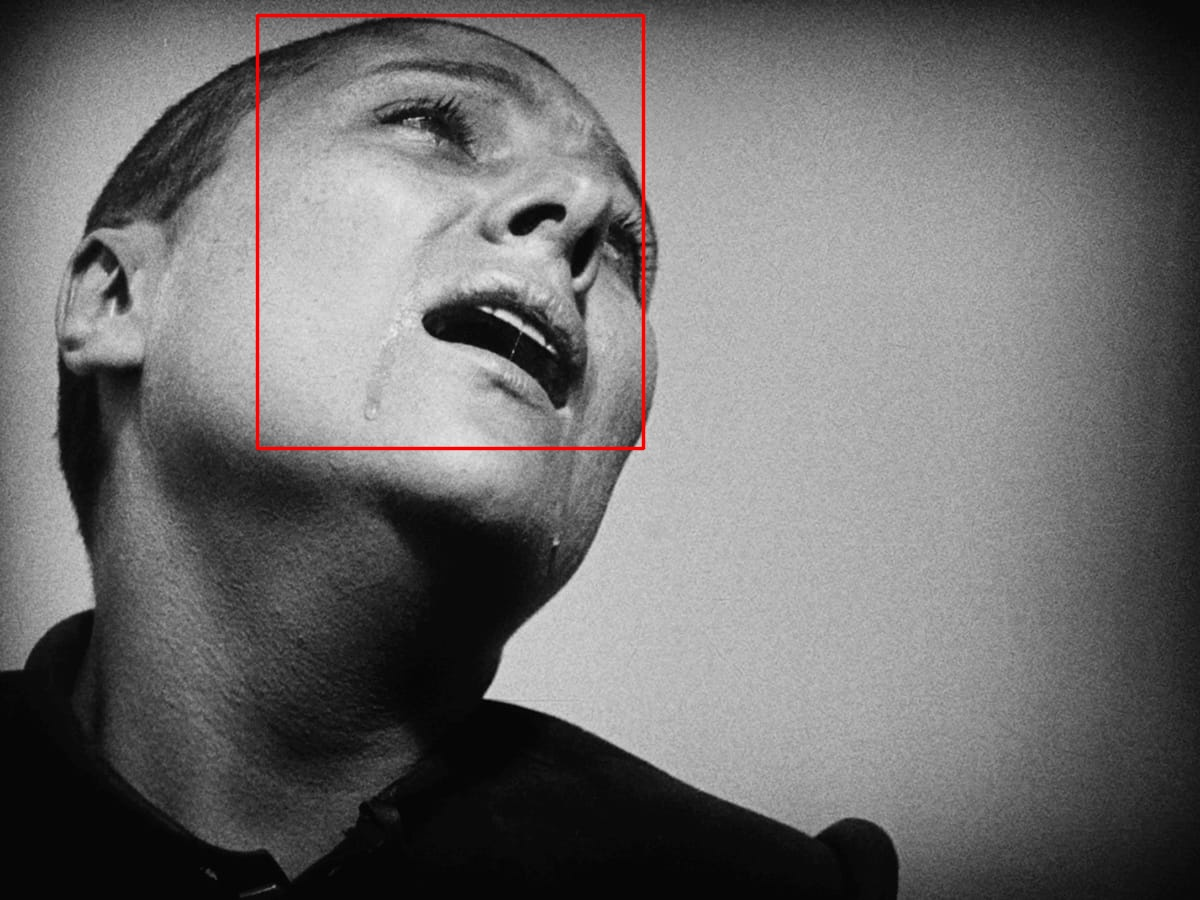

In [6]:
img = cv2.imread('../images/img_6.jpg')
annotation = model.predict_jsons(img)
draw_faces(img, annotation)

In [7]:
src = '/home/amos/datasets/test_videos/shining_bat.mp4'
cap = cv2.VideoCapture(src)
framecount = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frames = []
for frame_num in range(framecount):
    ret, frame = cap.read()
    if frame_num % 24 == 0:
        torched_image = tensor_from_rgb_image(frame)
        frames.append(torched_image)
    if len(frames) >= 4:
        tensor = torch.stack(frames).to('cuda')
        model.model(tensor.float())
        frames = []

In [9]:
model.model(tensor.float())

(tensor([[[ 1.4702,  1.3804,  0.3032, -0.0684],
          [ 2.3136,  2.9997,  1.2061,  0.4929],
          [ 0.9080,  1.2812,  0.6960, -0.3995],
          ...,
          [-0.3017,  0.5574, -1.1103, -1.1527],
          [-0.0204,  0.4212, -0.7628, -1.1013],
          [-0.0852,  0.7669, -0.9361, -1.3326]],
 
         [[ 1.8013,  1.3226,  0.8812, -0.0523],
          [ 1.6217,  3.7737,  1.3220,  0.2753],
          [ 1.3516,  0.9947,  1.3734,  0.2125],
          ...,
          [-0.2949,  0.5703, -1.1516, -1.2060],
          [-0.0375,  0.3776, -0.7715, -1.1443],
          [-0.0928,  0.7247, -0.9257, -1.3361]],
 
         [[ 1.4392,  1.7883,  0.0218, -0.6536],
          [ 1.4618,  3.4643,  0.5365,  0.0262],
          [ 1.0773,  1.5483,  0.6262, -0.5989],
          ...,
          [-0.3476,  0.5993, -1.1913, -1.2764],
          [-0.0280,  0.4224, -0.8017, -1.1946],
          [-0.1136,  0.7940, -0.8654, -1.4079]],
 
         [[ 0.8324,  1.6182, -0.6648, -0.4808],
          [ 1.9803,  2.1711,  0.33

: 